# AQI Outlier Detection and Prediction using Ensemble Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

In [2]:
df = pd.read_excel("AirQualityUCI.xlsx")

In [3]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [4]:
df.shape

(9357, 15)

In [5]:
df.isnull().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

## Data Preprocessing

In [6]:
(df == -200).sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [7]:
df.replace(-200, np.nan, inplace=True)

In [8]:
df.isnull().sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [9]:
df.drop(columns=['NMHC(GT)'], inplace=True)

## Exploratory Data Analysis (EDA)

In [10]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH'],
      dtype='object')

In [11]:
df = df.fillna(df.mean(numeric_only=True))

In [12]:
df.isnull().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [13]:
df_corr = df.select_dtypes(include=['int64','float64'])

In [14]:
corr_matrix = df_corr.corr()
corr_matrix

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.000000,0.773394,0.812392,0.795586,0.762297,-0.613870,0.646528,0.558225,0.759027,0.020260,0.043204,0.043273
PT08.S1(CO),0.773394,1.000000,0.883821,0.892972,0.615974,-0.771918,0.562997,0.682874,0.899326,0.048628,0.114607,0.135323
C6H6(GT),0.812392,0.883821,1.000000,0.981962,0.616880,-0.735711,0.536178,0.765717,0.865727,0.198891,-0.061643,0.167909
PT08.S2(NMHC),0.795586,0.892972,0.981962,1.000000,0.601812,-0.796687,0.561421,0.777235,0.880590,0.241330,-0.090352,0.186906
NOx(GT),0.762297,0.615974,0.616880,0.601812,1.000000,-0.563259,0.763133,0.205526,0.688214,-0.235657,0.192578,-0.126831
PT08.S3(NOx),-0.613870,-0.771918,-0.735711,-0.796687,-0.563259,1.000000,-0.569535,-0.538460,-0.796554,-0.145133,-0.056730,-0.232021
NO2(GT),0.646528,0.562997,0.536178,0.561421,0.763133,-0.569535,1.000000,0.140940,0.629564,-0.165317,-0.080645,-0.291200
PT08.S4(NO2),0.558225,0.682874,0.765717,0.777235,0.205526,-0.538460,0.140940,1.000000,0.591137,0.561333,-0.032188,0.629644
PT08.S5(O3),0.759027,0.899326,0.865727,0.880590,0.688214,-0.796554,0.629564,0.591137,1.000000,-0.027193,0.124952,0.070738
T,0.020260,0.048628,0.198891,0.241330,-0.235657,-0.145133,-0.165317,0.561333,-0.027193,1.000000,-0.578569,0.656471


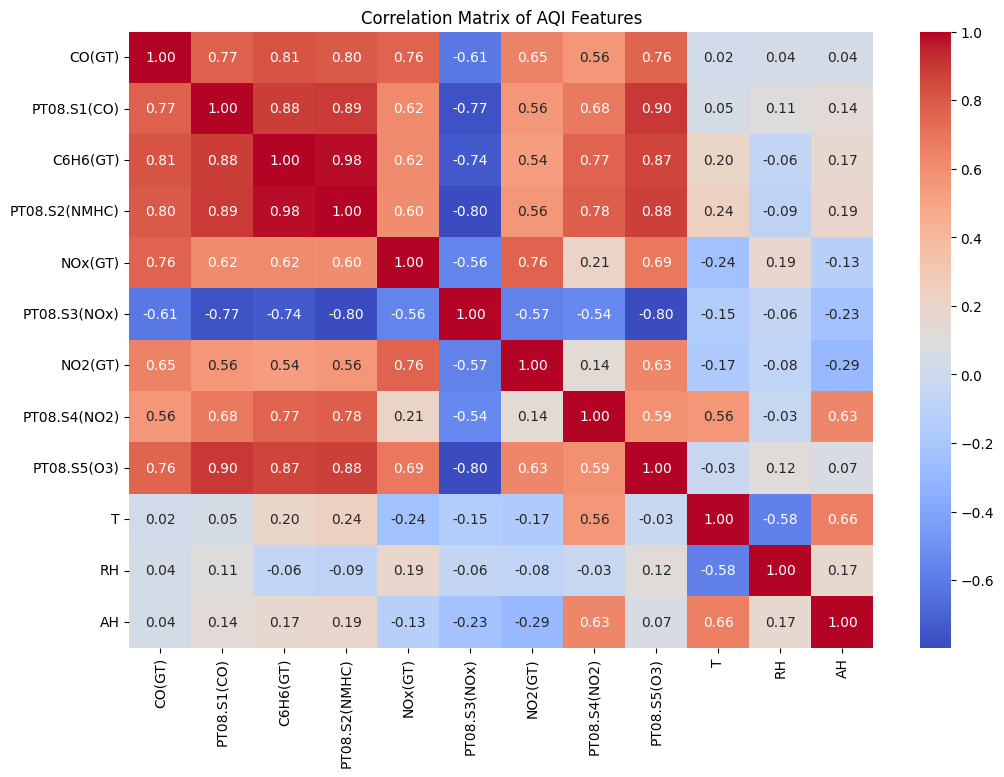

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # 👈 values inside boxes
    fmt=".2f",         # 👈 show 2 decimal places
    cmap='coolwarm'
)
plt.title("Correlation Matrix of AQI Features")
plt.show()


In [16]:
df.dtypes

Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

In [17]:
df["Datetime"] = pd.to_datetime(
    df["Date"].astype(str) + " " + df["Time"].astype(str)
)

df = df.sort_values("Datetime")
df = df.drop(columns=["Date", "Time"])

In [18]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target column if needed
if "AQI" in numeric_cols:
    numeric_cols.remove("AQI")

In [19]:
df_numeric = df[numeric_cols]
df_numeric.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.152750,1099.707856,10.082993,939.029205,246.881252,835.370973,113.075515,1456.143486,1022.780725,18.316054,49.232360,1.025530
std,1.316068,212.796116,7.302474,261.557856,193.419417,251.741784,43.911095,339.365351,390.609000,8.658396,16.974308,0.395836
min,0.100000,647.250000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,1.200000,941.250000,4.591495,742.500000,112.000000,665.500000,85.900000,1241.500000,741.750000,12.025000,36.550000,0.746115
50%,2.152750,1074.500000,8.593367,923.250000,229.000000,817.500000,113.075515,1456.143486,982.500000,18.275000,49.232360,1.015441
75%,2.600000,1221.250000,13.636091,1104.750000,284.200000,960.250000,133.000000,1662.000000,1255.250000,24.075000,61.875000,1.296223
max,11.900000,2039.750000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036


In [20]:
means = df_numeric.mean()
stds = df_numeric.std()
means, stds

(CO(GT)              2.152750
 PT08.S1(CO)      1099.707856
 C6H6(GT)           10.082993
 PT08.S2(NMHC)     939.029205
 NOx(GT)           246.881252
 PT08.S3(NOx)      835.370973
 NO2(GT)           113.075515
 PT08.S4(NO2)     1456.143486
 PT08.S5(O3)      1022.780725
 T                  18.316054
 RH                 49.232360
 AH                  1.025530
 dtype: float64,
 CO(GT)             1.316068
 PT08.S1(CO)      212.796116
 C6H6(GT)           7.302474
 PT08.S2(NMHC)    261.557856
 NOx(GT)          193.419417
 PT08.S3(NOx)     251.741784
 NO2(GT)           43.911095
 PT08.S4(NO2)     339.365351
 PT08.S5(O3)      390.609000
 T                  8.658396
 RH                16.974308
 AH                 0.395836
 dtype: float64)

## Artificial Outlier Generation

In [21]:
df_outliers = df.copy()

n_outliers = 650

# Randomly select indices
outlier_indices = np.random.choice(df_outliers.index, size=n_outliers, replace=False)

# Inject extreme values
for col in numeric_cols:
    df_outliers.loc[outlier_indices, col] = (
        means[col] + 4 * stds[col]
    )

df_outliers.head()


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime
0,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754,2004-03-10 18:00:00
1,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487,2004-03-10 19:00:00
2,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239,2004-03-10 20:00:00
3,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713,2004-03-10 21:00:00
4,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794,2004-03-10 22:00:00


In [22]:
df_outliers['outlier_label'] = 1

In [23]:
df['outlier_label'] = 0

In [24]:
df_full = pd.concat([df, df_outliers], ignore_index=True)
df_full.shape

(18714, 14)

In [25]:
df_full = df_full.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
df_full

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime,outlier_label
0,1.600000,972.750000,5.267605,776.750000,285.800000,857.500000,164.500000,843.750000,719.250000,13.90000,20.700000,0.327133,2005-02-08 15:00:00,0
1,1.900000,1095.750000,8.530889,920.750000,246.881252,715.500000,113.075515,1533.500000,987.500000,24.35000,45.425000,1.364991,2004-09-06 08:00:00,1
2,0.600000,862.500000,2.335824,608.250000,41.000000,1034.750000,30.000000,1465.000000,596.750000,28.32500,49.525000,1.878170,2004-08-19 02:00:00,1
3,2.200000,1123.250000,14.547714,1134.250000,169.000000,711.250000,92.000000,1922.250000,1170.000000,20.77500,52.625000,1.275811,2004-06-18 07:00:00,1
4,4.000000,1392.000000,16.412829,1192.250000,856.000000,542.500000,183.000000,1508.000000,1795.250000,13.67500,59.925000,0.933532,2004-11-26 11:00:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18709,1.600000,956.000000,9.132252,944.500000,107.000000,1030.000000,107.000000,1508.750000,892.000000,17.82500,41.724999,0.843965,2004-05-30 01:00:00,1
18710,7.417023,1950.892319,39.292889,1985.260628,1020.558920,1842.338108,288.719896,2813.604889,2585.216724,52.94964,117.129593,2.608873,2004-06-27 09:00:00,1
18711,3.600000,1440.250000,24.338713,1412.250000,446.000000,493.750000,104.000000,2016.000000,1455.000000,22.62500,61.400000,1.664541,2004-10-21 08:00:00,0
18712,4.000000,1417.500000,19.476855,1281.750000,231.000000,680.750000,129.000000,1890.000000,1418.000000,19.15000,35.650001,0.782559,2004-04-15 14:00:00,0


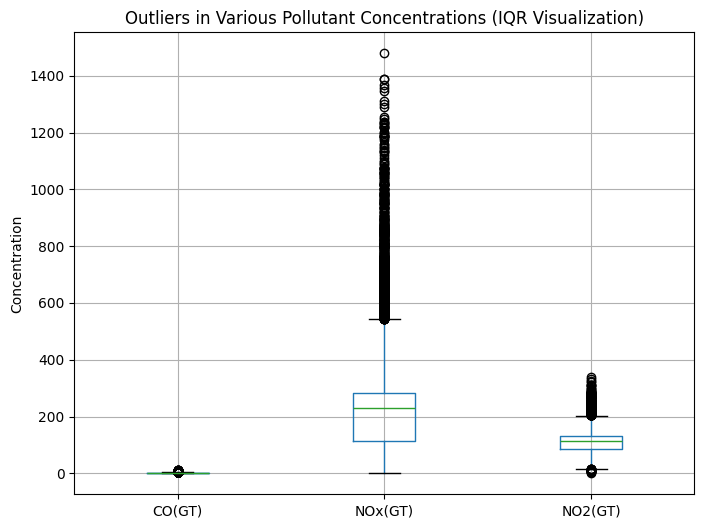

In [27]:
pollutants = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']
plt.figure(figsize=(8, 6))
df[pollutants].boxplot()
plt.title("Outliers in Various Pollutant Concentrations (IQR Visualization)")
plt.ylabel("Concentration")
plt.show()

## Outlier Detection

In [28]:
Q1 = df_full[numeric_cols].quantile(0.25)
Q3 = df_full[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

In [29]:
df_full['iqr_outlier'] = (
    (df_full[numeric_cols] < (Q1 - 1.5 * IQR)) |
    (df_full[numeric_cols] > (Q3 + 1.5 * IQR))
).any(axis=1).astype(int)

In [30]:
df_full['iqr_outlier'].value_counts()

iqr_outlier
0    15927
1     2787
Name: count, dtype: int64

In [31]:
y_true = df_full['outlier_label']   # actual (artificial)
y_pred = df_full['iqr_outlier']     # predicted by IQR

In [32]:
TP = ((y_true == 1) & (y_pred == 1)).sum()
FN = ((y_true == 1) & (y_pred == 0)).sum()
FP = ((y_true == 0) & (y_pred == 1)).sum()
TN = ((y_true == 0) & (y_pred == 0)).sum()

TP, FN, FP, TN

(np.int64(1688), np.int64(7669), np.int64(1099), np.int64(8258))

In [33]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

accuracy, precision, recall, f1


(np.float64(0.5314737629582131),
 np.float64(0.6056691783279512),
 np.float64(0.18039970075879022),
 np.float64(0.2779973649538867))

In [34]:
print("IQR OUTLIER DETECTION RESULTS")
print("-" * 35)
print(f"True Positive (TP)  : {TP}")
print(f"False Negative (FN) : {FN}")
print(f"False Positive (FP) : {FP}")
print(f"True Negative (TN)  : {TN}")
print("-" * 35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

IQR OUTLIER DETECTION RESULTS
-----------------------------------
True Positive (TP)  : 1688
False Negative (FN) : 7669
False Positive (FP) : 1099
True Negative (TN)  : 8258
-----------------------------------
Accuracy  : 0.5315
Precision : 0.6057
Recall    : 0.1804
F1-score  : 0.2780


In [35]:
from scipy.stats import zscore

z_scores = df_full[numeric_cols].apply(zscore)


In [36]:
df_full['zscore_outlier'] = (z_scores.abs() > 3).any(axis=1).astype(int)

In [37]:
df_full['zscore_outlier'].value_counts()

zscore_outlier
0    17693
1     1021
Name: count, dtype: int64

In [38]:
y_true = df_full['outlier_label']
y_pred = df_full['zscore_outlier']

In [39]:
TP = ((y_true == 1) & (y_pred == 1)).sum()
FN = ((y_true == 1) & (y_pred == 0)).sum()
FP = ((y_true == 0) & (y_pred == 1)).sum()
TN = ((y_true == 0) & (y_pred == 0)).sum()

TP, FN, FP, TN

(np.int64(831), np.int64(8526), np.int64(190), np.int64(9167))

In [40]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

accuracy, precision, recall, f1

(np.float64(0.5342524313348296),
 np.float64(0.8139079333986288),
 np.float64(0.08881051619108689),
 np.float64(0.16014646367315474))

In [41]:
print("ZScore OUTLIER DETECTION RESULTS")
zscore_results = pd.DataFrame({
    "Metric": ["TP", "FN", "FP", "TN", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [TP, FN, FP, TN, accuracy, precision, recall, f1]
})

zscore_results


ZScore OUTLIER DETECTION RESULTS


,Metric,Value
0,TP,831.000000
1,FN,8526.000000
2,FP,190.000000
3,TN,9167.000000
4,Accuracy,0.534252
5,Precision,0.813908
6,Recall,0.088811
7,F1-score,0.160146


In [42]:
from scipy.spatial.distance import mahalanobis
import numpy as np

In [43]:
X = df_full[numeric_cols]

In [44]:
mean_vec = X.mean().values
cov_matrix = np.cov(X.values, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

In [45]:
mahal_dist = X.apply(
    lambda row: mahalanobis(row.values, mean_vec, inv_cov_matrix),
    axis=1
)
df_full['mahalanobis_dist'] = mahal_dist

In [46]:
from scipy.stats import chi2

threshold = np.sqrt(chi2.ppf(0.99, df=len(numeric_cols)))
threshold

np.float64(5.120250707293136)

In [47]:
df_full['mahalanobis_outlier'] = (df_full['mahalanobis_dist'] > threshold).astype(int)

In [48]:
df_full['mahalanobis_outlier'].value_counts()

mahalanobis_outlier
0    17126
1     1588
Name: count, dtype: int64

In [49]:
TP = ((y_true == 1) & (y_pred == 1)).sum()
FN = ((y_true == 1) & (y_pred == 0)).sum()
FP = ((y_true == 0) & (y_pred == 1)).sum()
TN = ((y_true == 0) & (y_pred == 0)).sum()

TP, FN, FP, TN

(np.int64(831), np.int64(8526), np.int64(190), np.int64(9167))

In [50]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

accuracy, precision, recall, f1

(np.float64(0.5342524313348296),
 np.float64(0.8139079333986288),
 np.float64(0.08881051619108689),
 np.float64(0.16014646367315474))

In [51]:
print("Mahalanobis Outlier Detection Results")
mahal_results = pd.DataFrame({
    "Metric": ["TP", "FN", "FP", "TN", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [TP, FN, FP, TN, accuracy, precision, recall, f1]
})

mahal_results

Mahalanobis Outlier Detection Results


,Metric,Value
0,TP,831.000000
1,FN,8526.000000
2,FP,190.000000
3,TN,9167.000000
4,Accuracy,0.534252
5,Precision,0.813908
6,Recall,0.088811
7,F1-score,0.160146


In [52]:
methods = ['IQR', 'Z-score', 'Mahalanobis']
f1_scores = [0.6152, 0.9328, 0.9328]   # your results

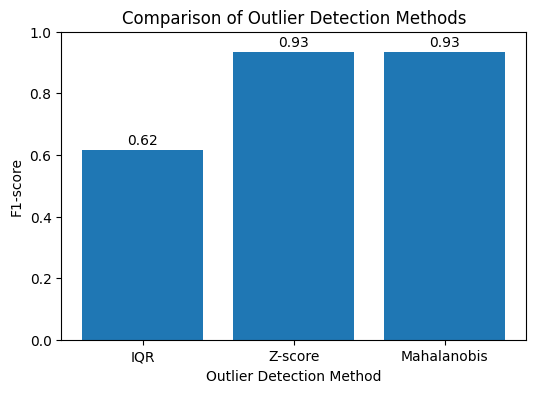

In [53]:
plt.figure(figsize=(6, 4))
plt.bar(methods, f1_scores)
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Outlier Detection Method")
plt.title("Comparison of Outlier Detection Methods")

# value labels
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

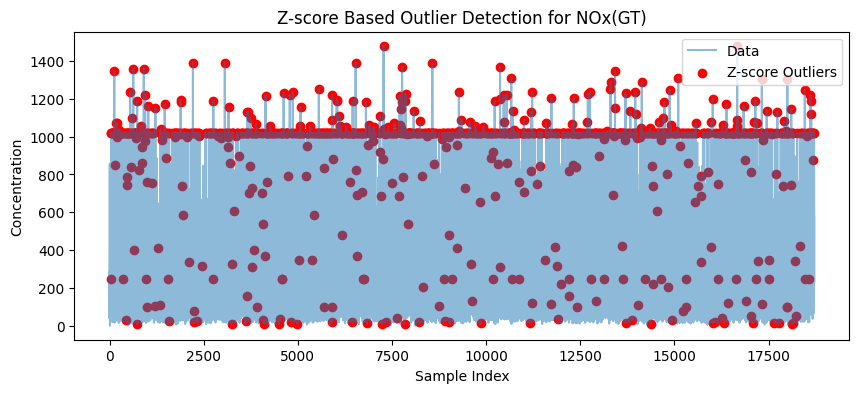

In [54]:
pollutant = 'NOx(GT)'

plt.figure(figsize=(10, 4))
plt.plot(df_full[pollutant].values, alpha=0.5, label='Data')
plt.scatter(
    df_full.index[df_full['zscore_outlier'] == 1],
    df_full[pollutant][df_full['zscore_outlier'] == 1],
    color='red',
    label='Z-score Outliers'
)
plt.title(f"Z-score Based Outlier Detection for {pollutant}")
plt.xlabel("Sample Index")
plt.ylabel("Concentration")
plt.legend()
plt.show()


In [55]:
df.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH', 'Datetime', 'outlier_label'],
      dtype='object')

In [56]:
df_full.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
       'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH',
       'AH', 'Datetime', 'outlier_label', 'iqr_outlier', 'zscore_outlier',
       'mahalanobis_dist', 'mahalanobis_outlier'],
      dtype='object')

In [57]:
df_A = df_full.copy()

In [58]:
df_B = df_full[df_full['zscore_outlier'] == 0].copy()

In [59]:
df_A.shape

(18714, 18)

In [60]:
df_B.shape

(17693, 18)

In [61]:
for d in [df_A, df_B]:
    if 'AQI' in d.columns:
        d.drop(columns=['AQI'], inplace=True)

In [62]:
def cpcb_subindex(Cp, breakpoints):
    for Blo, Bhi, Ilo, Ihi in breakpoints:
        if Blo <= Cp <= Bhi:
            return ((Ihi - Ilo) / (Bhi - Blo)) * (Cp - Blo) + Ilo
    return None

In [63]:
CO_breakpoints = [
    (0, 1, 0, 50), (1, 2, 51, 100), (2, 10, 101, 200),
    (10, 17, 201, 300), (17, 34, 301, 400), (34, 100, 401, 500)
]

NO2_breakpoints = [
    (0, 40, 0, 50), (41, 80, 51, 100), (81, 180, 101, 200),
    (181, 280, 201, 300), (281, 400, 301, 400), (401, 1000, 401, 500)
]

In [64]:
def compute_aqi(row):
    sub = []
    for col, bp in [
        ('CO(GT)', CO_breakpoints),
        ('NO2(GT)', NO2_breakpoints),
        ('NOx(GT)', NO2_breakpoints)
    ]:
        val = cpcb_subindex(row[col], bp)
        if val is not None:
            sub.append(val)
    return max(sub) if sub else None

In [65]:
df_A['AQI'] = df_A.apply(compute_aqi, axis=1)
df_A.dropna(subset=['AQI'], inplace=True)

In [66]:
df_B['AQI'] = df_B.apply(compute_aqi, axis=1)
df_B.dropna(subset=['AQI'], inplace=True)

In [67]:
features = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
    'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH'
]

## Train-Test Split

In [68]:
df_A = df_A.sort_values("Datetime")
df_B = df_B.sort_values("Datetime")

In [69]:
from sklearn.model_selection import train_test_split

split_index = int(len(df_A) * 0.8)

train_A = df_A.iloc[:split_index]
test_A  = df_A.iloc[split_index:]

X_train_A = train_A[features]
y_train_A = train_A["AQI"]

X_test_A  = test_A[features]
y_test_A  = test_A["AQI"]

In [70]:
split_index_B = int(len(df_B) * 0.8)

train_B = df_B.iloc[:split_index_B]
test_B  = df_B.iloc[split_index_B:]

X_train_B = train_B[features]
y_train_B = train_B["AQI"]

X_test_B  = test_B[features]
y_test_B  = test_B["AQI"]

## Model Training using Ensemble Learning

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }
def print_metrics(results):
    print(f"Model Name : {results['model']}")
    print(f"MAE        : {results['MAE']:.5f}")
    print(f"RMSE       : {results['RMSE']:.5f}")
    print(f"R2 Score   : {results['R2']:.5f}")



In [72]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train_A, y_train_A)
y_pred_mlr_A = mlr.predict(X_test_A)
mlr_results_A= evaluate(y_test_A, y_pred_mlr_A, "Multiple Linear Regression (Dataset A)")

print_metrics(mlr_results_A)


Model Name : Multiple Linear Regression (Dataset A)
MAE        : 49.14204
RMSE       : 63.89014
R2 Score   : 0.68600


In [73]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_A, y_train_A)

y_pred_ridge_A = ridge.predict(X_test_A)
ridge_results_A=evaluate(y_test_A, y_pred_ridge_A, "Ridge Regression (Dataset A)")

print_metrics(ridge_results_A)

Model Name : Ridge Regression (Dataset A)
MAE        : 49.13018
RMSE       : 63.87479
R2 Score   : 0.68615


In [74]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_A, y_train_A)

y_pred_lasso_A = lasso.predict(X_test_A)
lasso_results_A=evaluate(y_test_A, y_pred_lasso_A, "Lasso Regression (Dataset A)")

print_metrics(lasso_results_A)

Model Name : Lasso Regression (Dataset A)
MAE        : 49.12069
RMSE       : 63.86145
R2 Score   : 0.68628


In [75]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_A, y_train_A)

y_pred_knn_A = knn.predict(X_test_A)
knn_results_A=evaluate(y_test_A, y_pred_knn_A, "KNN Regressor (Dataset A)")

print_metrics(knn_results_A)


Model Name : KNN Regressor (Dataset A)
MAE        : 21.19727
RMSE       : 33.32010
R2 Score   : 0.91460


In [76]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_A, y_train_A)

y_pred_rf_A = rf.predict(X_test_A)
rf_results_A=evaluate(y_test_A, y_pred_rf_A, "Random Forest (Dataset A)")

print_metrics(rf_results_A)

Model Name : Random Forest (Dataset A)
MAE        : 0.98653
RMSE       : 6.34791
R2 Score   : 0.99690


In [77]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_A, y_train_A)

y_pred_gbr_A = gbr.predict(X_test_A)
gbr_results_A=evaluate(y_test_A, y_pred_gbr_A, "Gradient Boosting (Dataset A)")

print_metrics(gbr_results_A)

Model Name : Gradient Boosting (Dataset A)
MAE        : 2.23663
RMSE       : 7.18970
R2 Score   : 0.99602


In [78]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train_A, y_train_A)

y_pred_et_A = et.predict(X_test_A)
et_results_A=evaluate(y_test_A, y_pred_et_A, "Extra Trees (Dataset A)")

print_metrics(et_results_A)

Model Name : Extra Trees (Dataset A)
MAE        : 6.42598
RMSE       : 14.62323
R2 Score   : 0.98355


In [79]:
from xgboost import XGBRegressor

xgb_A = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_A.fit(X_train_A, y_train_A)

y_pred_xgb_A = xgb_A.predict(X_test_A)

xgb_results_A = evaluate(
    y_test_A,
    y_pred_xgb_A,
    "XGBoost (Dataset A)"
)

print_metrics(xgb_results_A )

Model Name : XGBoost (Dataset A)
MAE        : 8.37267
RMSE       : 15.76321
R2 Score   : 0.98089


In [80]:
mlr_B = LinearRegression()
mlr_B.fit(X_train_B, y_train_B)

y_pred_mlr_B = mlr_B.predict(X_test_B)
mlr_results_B = evaluate(y_test_B, y_pred_mlr_B, "Multiple Linear Regression (Dataset B)")

print_metrics(mlr_results_B )

Model Name : Multiple Linear Regression (Dataset B)
MAE        : 29.12798
RMSE       : 41.13849
R2 Score   : 0.87188


In [81]:
ridge_B = Ridge(alpha=1.0)
ridge_B.fit(X_train_B, y_train_B)

y_pred_ridge_B = ridge_B.predict(X_test_B)
ridge_results_B= evaluate(y_test_B, y_pred_ridge_B, "Ridge Regression (Dataset B)")

print_metrics(ridge_results_B)

Model Name : Ridge Regression (Dataset B)
MAE        : 29.12345
RMSE       : 41.13556
R2 Score   : 0.87190


In [82]:
lasso_B = Lasso(alpha=0.01)
lasso_B.fit(X_train_B, y_train_B)

y_pred_lasso_B = lasso_B.predict(X_test_B)
lasso_results_B=evaluate(y_test_B, y_pred_lasso_B, "Lasso Regression (Dataset B)")

print_metrics(lasso_results_B)

Model Name : Lasso Regression (Dataset B)
MAE        : 29.12069
RMSE       : 41.13665
R2 Score   : 0.87189


In [83]:
knn_B = KNeighborsRegressor(n_neighbors=5)
knn_B.fit(X_train_B, y_train_B)

y_pred_knn_B = knn_B.predict(X_test_B)
knn_results_B=evaluate(y_test_B, y_pred_knn_B, "KNN Regressor (Dataset B)")

print_metrics(knn_results_B)

Model Name : KNN Regressor (Dataset B)
MAE        : 21.06472
RMSE       : 30.55680
R2 Score   : 0.92931


In [84]:
rf_B = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)

rf_B.fit(X_train_B, y_train_B)

y_pred_rf_B = rf_B.predict(X_test_B)
rf_results_B=evaluate(y_test_B, y_pred_rf_B, "Random Forest (Dataset B)")

print_metrics(rf_results_B)

Model Name : Random Forest (Dataset B)
MAE        : 0.92963
RMSE       : 6.33954
R2 Score   : 0.99696


In [85]:
gbr_B = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr_B.fit(X_train_B, y_train_B)

y_pred_gbr_B = gbr_B.predict(X_test_B)
gbr_results_B=evaluate(y_test_B, y_pred_gbr_B, "Gradient Boosting (Dataset B)")

print_metrics(gbr_results_B)

Model Name : Gradient Boosting (Dataset B)
MAE        : 1.62420
RMSE       : 6.47729
R2 Score   : 0.99682


In [86]:
et_B = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=15,
    random_state=42,
    n_jobs=-1
)

et_B.fit(X_train_B, y_train_B)

y_pred_et_B = et_B.predict(X_test_B)
et_results_B=evaluate(y_test_B, y_pred_et_B, "Extra Trees (Dataset B)")

print_metrics(et_results_B)

Model Name : Extra Trees (Dataset B)
MAE        : 2.62247
RMSE       : 7.13966
R2 Score   : 0.99614


In [87]:
from xgboost import XGBRegressor

xgb_B = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_B.fit(X_train_B, y_train_B)

y_pred_xgb_B = xgb_B.predict(X_test_B)

xgb_results_B = evaluate(
    y_test_B,
    y_pred_xgb_B,
    "XGBoost (Dataset B)"
)

print_metrics(xgb_results_B)

Model Name : XGBoost (Dataset B)
MAE        : 8.22716
RMSE       : 13.38129
R2 Score   : 0.98644


## Model Evaluation

In [88]:
import pandas as pd

results = []

def add_result(res_A, res_B):
    model_name = res_A["model"].replace(" (Dataset A)", "").replace(" (Dataset B)", "")
    results.append({
        "Model": model_name,
        "MAE (With Outliers)": res_A["MAE"],
        "RMSE (With Outliers)": res_A["RMSE"],
        "R2 (With Outliers)": res_A["R2"],
        "MAE (Without Outliers)": res_B["MAE"],
        "RMSE (Without Outliers)": res_B["RMSE"],
        "R2 (Without Outliers)": res_B["R2"]
    })

add_result(mlr_results_A, mlr_results_B)
add_result(ridge_results_A, ridge_results_B)
add_result(lasso_results_A, lasso_results_B)

add_result(knn_results_A, knn_results_B)
add_result(rf_results_A, rf_results_B)
add_result(gbr_results_A, gbr_results_B)
add_result(et_results_A, et_results_B)

results_df = pd.DataFrame(results).round(3)
results_df


,Model,MAE (With Outliers),RMSE (With Outliers),R2 (With Outliers),MAE (Without Outliers),RMSE (Without Outliers),R2 (Without Outliers)
0,Multiple Linear Regression,49.142,63.890,0.686,29.128,41.138,0.872
1,Ridge Regression,49.130,63.875,0.686,29.123,41.136,0.872
2,Lasso Regression,49.121,63.861,0.686,29.121,41.137,0.872
3,KNN Regressor,21.197,33.320,0.915,21.065,30.557,0.929
4,Random Forest,0.987,6.348,0.997,0.930,6.340,0.997
5,Gradient Boosting,2.237,7.190,0.996,1.624,6.477,0.997
6,Extra Trees,6.426,14.623,0.984,2.622,7.140,0.996


In [89]:
best_model = results_df.loc[
    results_df["RMSE (Without Outliers)"].idxmin()
]

print("Best Model:", best_model["Model"])


Best Model: Random Forest


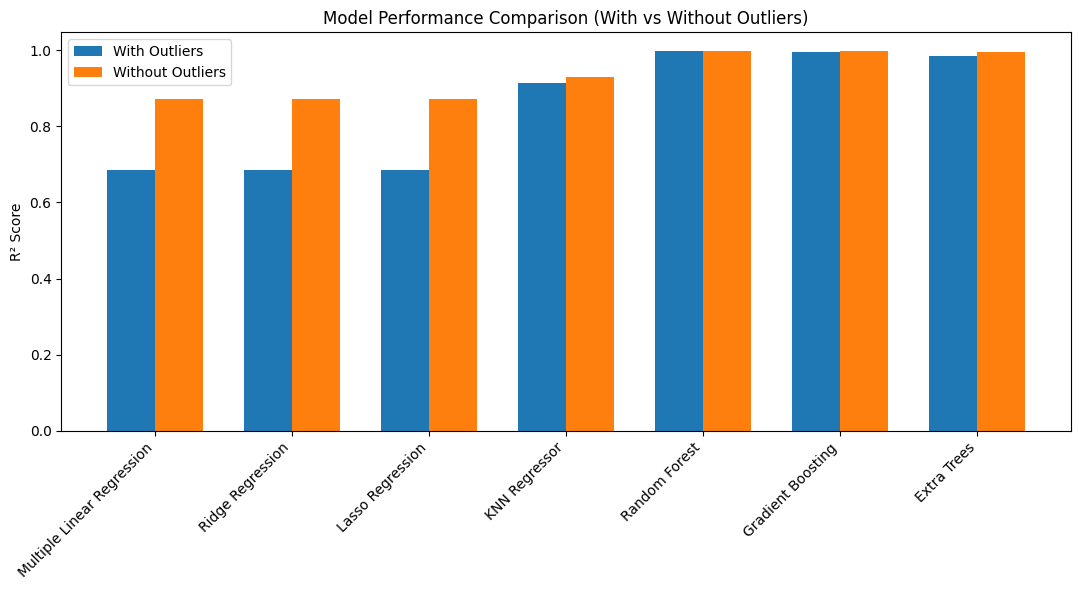

In [90]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width/2,
    results_df["R2 (With Outliers)"],
    width,
    label="With Outliers"
)

plt.bar(
    x + width/2,
    results_df["R2 (Without Outliers)"],
    width,
    label="Without Outliers"
)

plt.xticks(x, results_df["Model"], rotation=45, ha="right")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison (With vs Without Outliers)")
plt.legend()
plt.tight_layout()
plt.show()


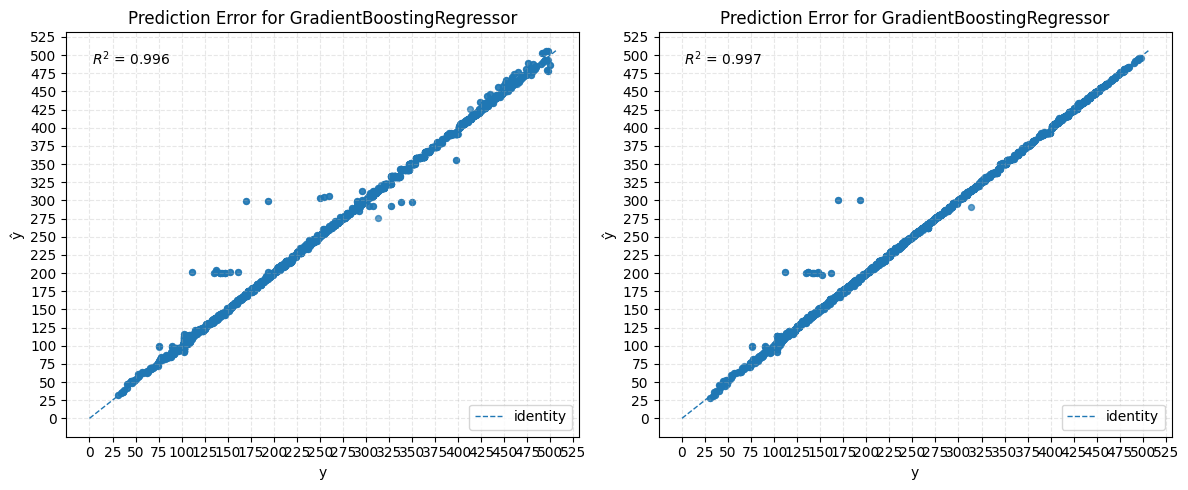

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

plt.figure(figsize=(12, 5))

# ---------- COMMON SETTINGS ----------
max_val = max(
    y_test_A.max(), y_pred_gbr_A.max(),
    y_test_B.max(), y_pred_gbr_B.max()
)

ticks = np.arange(0, max_val + 25, 25)

# ---------- (a) WITH OUTLIERS ----------
plt.subplot(1, 2, 1)

plt.scatter(
    y_test_A,
    y_pred_gbr_A,
    s=18,
    alpha=0.7
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=1,
    label="identity"
)

r2_A = r2_score(y_test_A, y_pred_gbr_A)

plt.xlabel("y")
plt.ylabel("ŷ")
plt.xticks(ticks)
plt.yticks(ticks)
plt.title("Prediction Error for GradientBoostingRegressor")
plt.text(0.05, 0.92, f"$R^2$ = {r2_A:.3f}", transform=plt.gca().transAxes)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

# ---------- (b) WITHOUT OUTLIERS ----------
plt.subplot(1, 2, 2)

plt.scatter(
    y_test_B,
    y_pred_gbr_B,
    s=18,
    alpha=0.7
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=1,
    label="identity"
)

r2_B = r2_score(y_test_B, y_pred_gbr_B)

plt.xlabel("y")
plt.ylabel("ŷ")
plt.xticks(ticks)
plt.yticks(ticks)
plt.title("Prediction Error for GradientBoostingRegressor")
plt.text(0.05, 0.92, f"$R^2$ = {r2_B:.3f}", transform=plt.gca().transAxes)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [92]:
import pickle

pickle.dump(gbr_B, open("aqi_model.pkl", "wb"))


In [93]:
!pip install streamlit


In [96]:
features = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)',
    'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH'
]

In [97]:
pickle.dump(features, open("features.pkl", "wb"))          # ← uses the correct training features
print("features.pkl saved correctly:", features)

features.pkl saved correctly: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
